# Análisis Evolutivo — Modelo Virus (NetLogo)

Este notebook analiza la **evolución temporal** del modelo *Virus* de NetLogo.
En lugar de ver solo el resultado final, observamos cómo cambia el número de
tortugas enfermas en cada tick de la simulación, para distintos valores de infectividad.

## 1. Cargar tidyverse

Cargamos la librería `tidyverse`, que incluye `ggplot2` para visualización y `dplyr` para manipulación de datos.

In [4]:
library(tidyverse)

## 2. Leer el CSV evolutivo

Cargamos el archivo CSV exportado desde BehaviorSpace. Los primeros 6 renglones contienen metadatos del experimento, por eso usamos `skip = 6`.

In [5]:
url <- "https://raw.githubusercontent.com/samegi/TCom-Analisis-NetLogo/main/virus_infectiousness_evolucion.csv"
data <- read.csv(url, encoding = "UTF-8", skip = 6)

## 3. Inspeccionar columnas

Revisamos la estructura del dataset: nombres de columnas, tipos de datos y las primeras filas para entender qué registró el experimento.

In [6]:
head(data)
names(data)
glimpse(data)

,X.run.number.,infectiousness,X.step.,count.turtles.with..sick..
,<int>,<int>,<int>,<int>
1,3,10,0,10
2,1,10,0,10
3,3,10,1,10
4,3,10,2,10
5,3,10,3,10
6,1,10,1,10


[1] "X.run.number."              "infectiousness"            
[3] "X.step."                    "count.turtles.with..sick.."

Rows: 15,030
Columns: 4
$ X.run.number.              <int> 3, 1, 3, 3, 3, 1, 2, 1, 3, 3, 3, 3, 3, 3, 3…
$ infectiousness             <int> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,…
$ X.step.                    <int> 0, 0, 1, 2, 3, 1, 0, 2, 4, 5, 6, 7, 8, 9, 1…
$ count.turtles.with..sick.. <int> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,…


## 4. Renombrar las columnas

Asignamos nombres simples a las 4 columnas:

| Columna original | Nuevo nombre | Descripción |
|---|---|---|
| X.run.number. | corrida | Número de repetición |
| infectiousness | parametro | Valor de infectividad |
| X.step. | tiempo | Tick de la simulación |
| count.turtles.with..sick.. | valor_temporal | Tortugas enfermas en ese tick |

In [7]:
colnames(data) <- c("corrida", "parametro", "tiempo", "valor_temporal")

## 5. Seleccionar el parámetro y la métrica final

Filtramos solo las dos columnas relevantes para el análisis: el parámetro manipulado (`infectividad`) y la métrica de resultado (`enfermos`).

In [8]:
datas <- data %>%
  select(corrida, parametro, tiempo, valor_temporal)

## 6. Graficar tiempo contra valor_temporal

Primera visualización: cómo evoluciona el número de enfermos a lo largo
de los ticks. Cada línea representa una corrida del modelo.

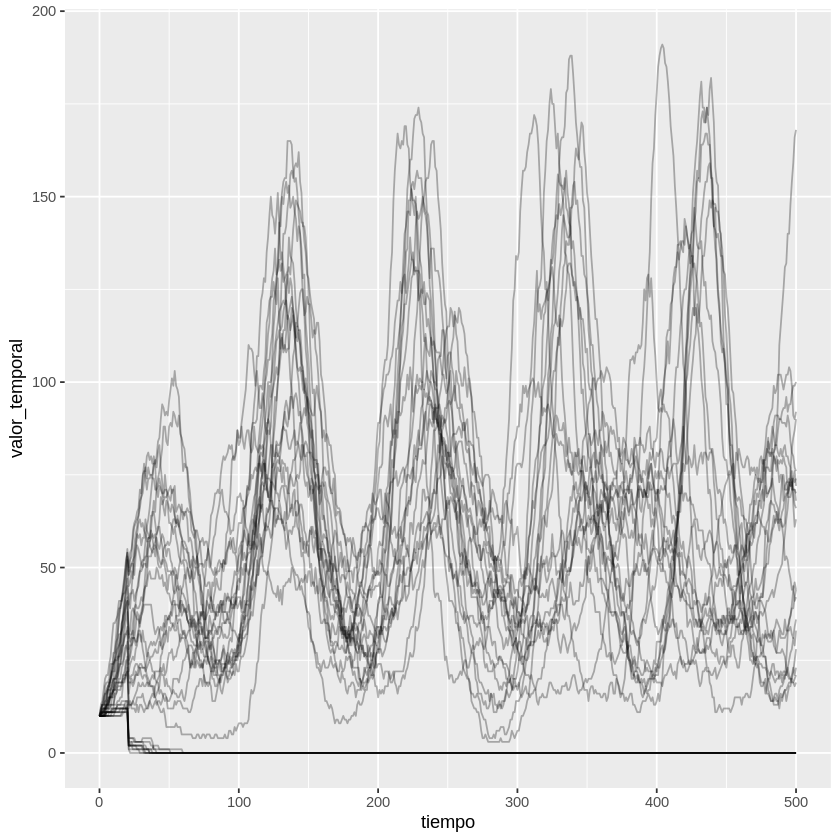

In [10]:
datas %>%
  ggplot(aes(tiempo, valor_temporal)) +
  geom_line(aes(group = corrida), alpha = 0.3)

## 7. Colorear por parámetro

Añadimos color para distinguir qué corridas pertenecen a cada nivel de infectividad.

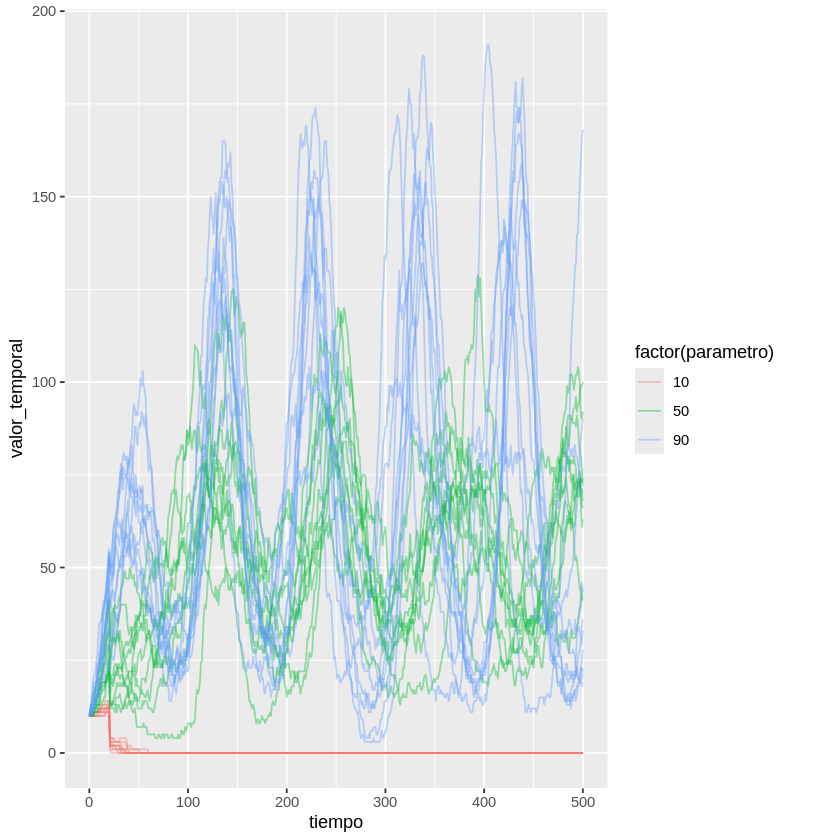

In [11]:
datas %>%
  ggplot(aes(tiempo, valor_temporal, color = factor(parametro))) +
  geom_line(aes(group = corrida), alpha = 0.4)

## Interpretación — Evolución individual por corrida

La gráfica muestra todas las corridas simultáneamente. Se observan tres
comportamientos claramente diferenciados según el nivel de infectividad:

- **Infectividad 10 (rojo):** todas las corridas convergen rápidamente
  a cero enfermos antes del tick 50 y permanecen ahí hasta el final.
  El virus se extingue en todos los casos sin excepción.

- **Infectividad 50 (verde):** las corridas muestran oscilaciones
  sostenidas entre ~0 y ~120 enfermos a lo largo de los 500 ticks.
  La epidemia no se extingue pero tampoco se estabiliza: el virus
  circula de forma endémica con brotes recurrentes.

- **Infectividad 90 (azul):** las corridas presentan las oscilaciones
  más amplias y frecuentes, llegando hasta ~190 enfermos en los picos.
  La separación entre corridas es mayor, lo que indica alta
  variabilidad estocástica: con el mismo parámetro, cada corrida
  toma un camino distinto.

## 8. Agrupar por parámetro y tiempo — calcular promedio

En lugar de ver todas las corridas individuales, calculamos el promedio
de enfermos en cada tick para cada nivel de infectividad.
Esto suaviza el ruido estocástico y muestra la tendencia central.

In [13]:
promedios <- datas %>%
  group_by(parametro, tiempo) %>%
  summarise(media = mean(valor_temporal), .groups = "drop")

## 9. Graficar líneas de evolución temporal

Graficamos el promedio de enfermos por tick para cada nivel de infectividad.
Cada línea representa la dinámica promedio del modelo bajo ese parámetro.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


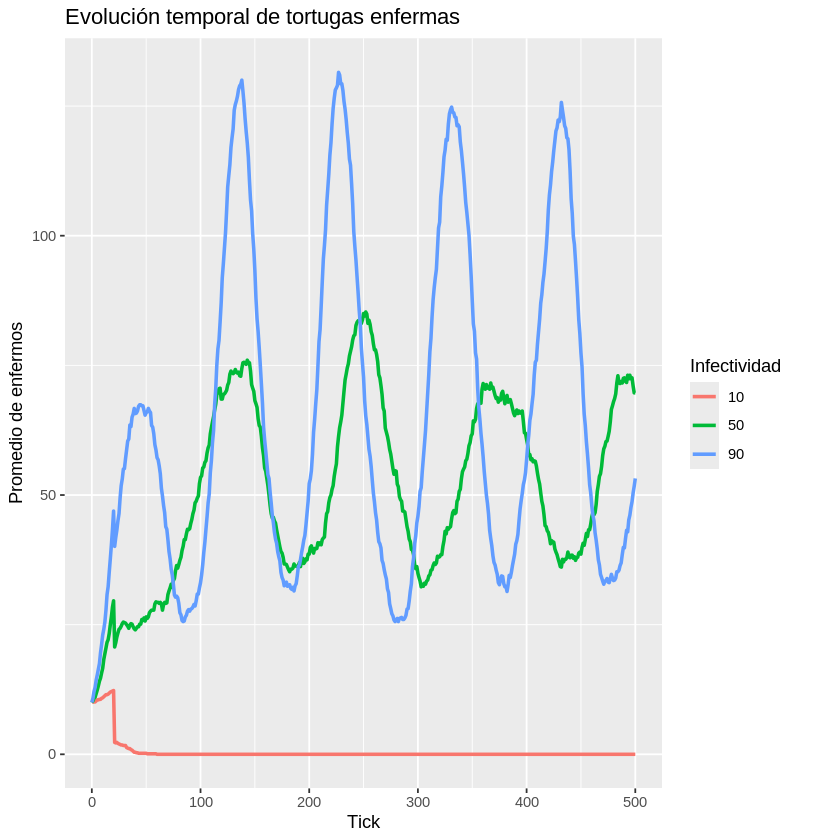

In [14]:
promedios %>%
  ggplot(aes(tiempo, media, color = factor(parametro))) +
  geom_line(size = 1) +
  labs(
    title = "Evolución temporal de tortugas enfermas",
    x = "Tick",
    y = "Promedio de enfermos",
    color = "Infectividad"
  )

## 10. Separar grupos con facet_wrap

Separamos cada nivel de infectividad en un panel propio para comparar
las curvas sin superposición.

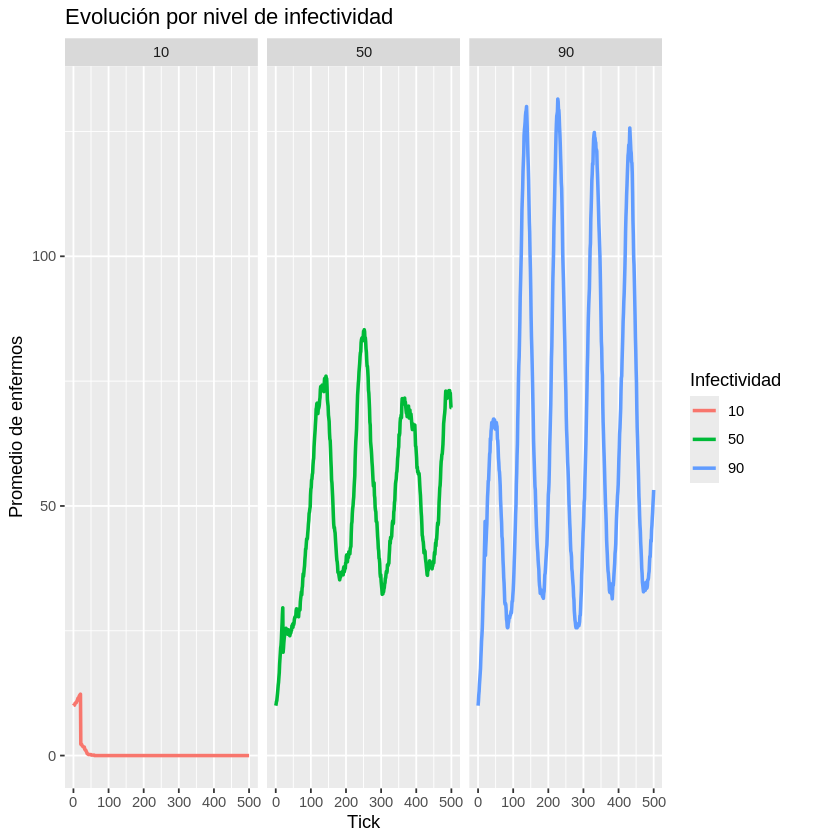

In [15]:
promedios %>%
  ggplot(aes(tiempo, media, color = factor(parametro))) +
  geom_line(size = 1) +
  facet_wrap(~ parametro) +
  labs(
    title = "Evolución por nivel de infectividad",
    x = "Tick",
    y = "Promedio de enfermos",
    color = "Infectividad"
  )

## 11. Interpretación — Dinámica temporal por nivel de infectividad

### Infectividad = 10
El virus se extingue en los primeros ~30 ticks. El promedio cae
a cero y no vuelve a subir. Con una infectividad tan baja, el virus
no logra propagarse suficientemente rápido antes de que los agentes
se recuperen, por lo que la epidemia colapsa sola.

### Infectividad = 50
Se observa un patrón **endémico oscilatorio**: el número de enfermos
sube y baja repetidamente entre ~20 y ~85 durante toda la simulación.
Los brotes ocurren aproximadamente cada 100 ticks. Esto indica que
el virus logra sostenerse en la población: cuando los enfermos se
recuperan, quedan suficientes susceptibles para alimentar un nuevo brote.

### Infectividad = 90
La dinámica es la más intensa: picos que superan los 130 enfermos en
promedio, con ciclos más frecuentes y pronunciados que los de infectividad 50.
El virus se propaga tan rápido que agota los susceptibles rápidamente,
lo que provoca una caída brusca seguida de una recuperación igual de rápida.

### Conclusión general
El parámetro `infectividad` determina cualitativamente el tipo de dinámica:

| Infectividad | Comportamiento |
|---|---|
| 10 | Extinción temprana |
| 50 | Endemia oscilatoria moderada |
| 90 | Epidemia cíclica de alta intensidad |

A mayor infectividad, el modelo no solo produce más enfermos sino un
sistema más inestable, con brotes más grandes y más difíciles de predecir
corrida a corrida.